In [1]:
words = open('isimler.txt', 'r').read().splitlines()

In [2]:
import torch

In [3]:
chars = sorted(list(set(''.join(words)))) #alfabeyi elde etmek için
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [4]:
N = torch.zeros((len(stoi), len(stoi)), dtype=torch.int32)

In [5]:
for w in words:
    chs = ['.'] + list(w) + ['.']  #w burda her bir kelime listedeki, bunu list(w) yapınca her bir harfini içeren liste dönüyor.
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

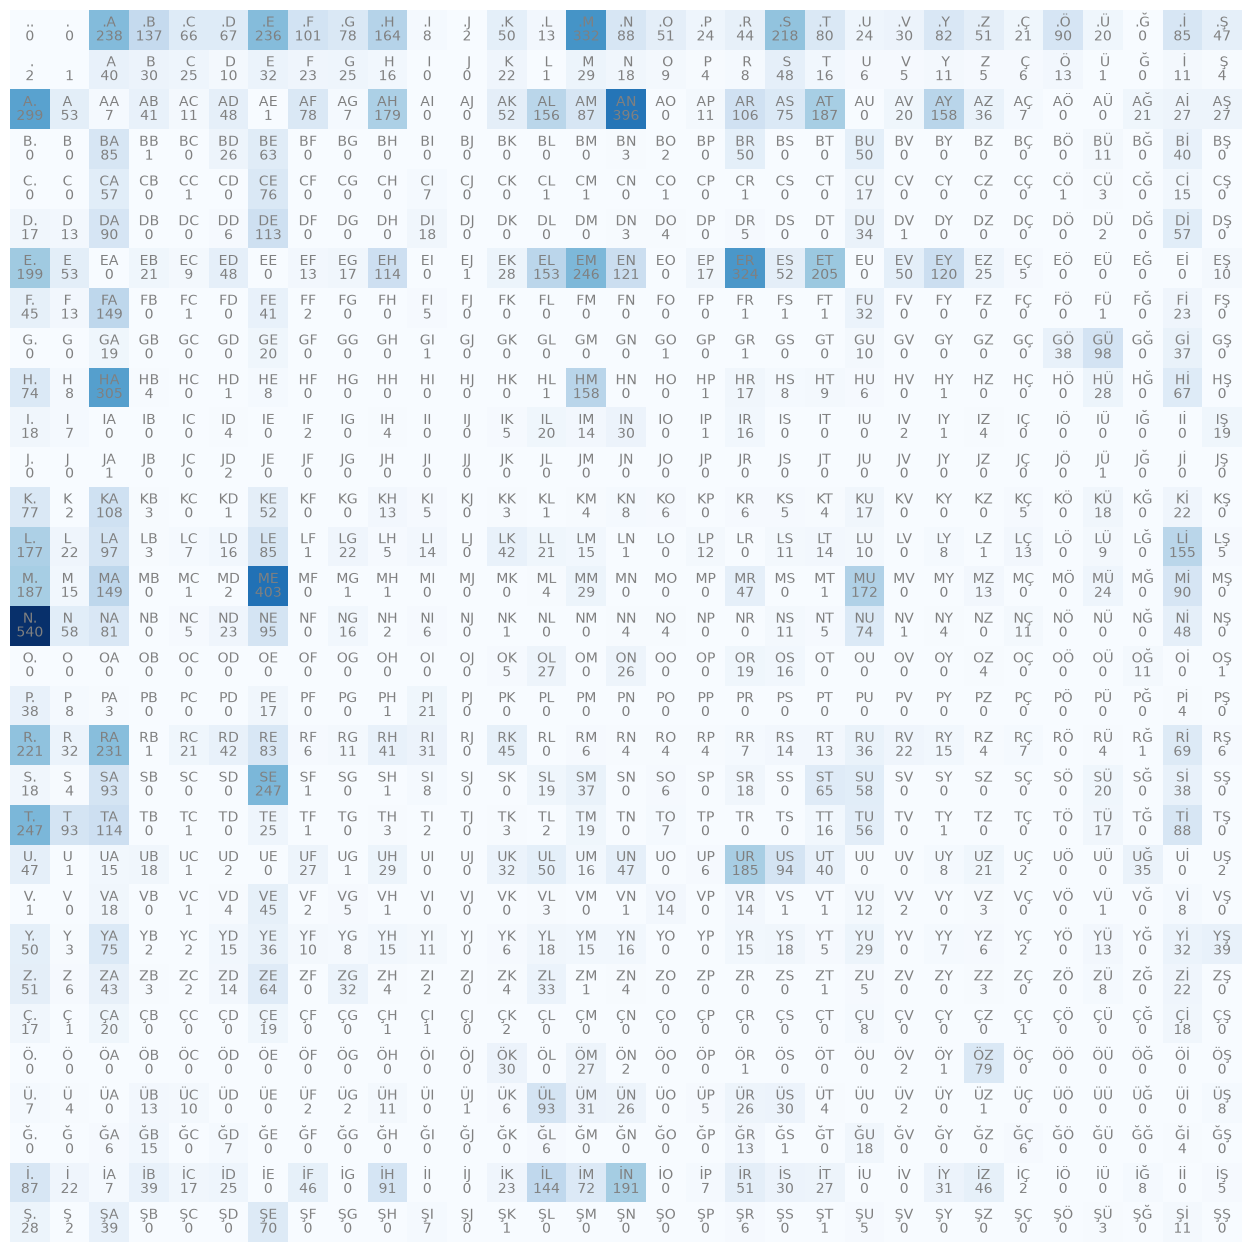

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(len(stoi)):
    for j in range(len(stoi)):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [7]:
P = (N + 1).float()  #andrej gibi örneklerde infinite loss bulmamak için yaptık N+1 işini. Hiç art arda gelmseler bile ufacık bir ihtimal de olsa model buna imkan tanısın.
P /= P.sum(1, keepdim=True) #broadcasting rules gecerli önemli tensor carpımı icin. Olasılık buluyoruz bu kısımda kısaca.
# P[0].sum()

In [10]:
# g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True).item() #multinomial generator için en sonda generator=g alabilir, farklı ihtimaller görmek adına kullanmadım.
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

KÜSET.
GÜŞA GÜN.
ENA.
SEL.
SUL.


In [9]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2] #P matrisinde bu ikilinin art arda gelmesine karşılık gelen o hücreye gidiyoruz direkt.
        logprob = torch.log(prob) #gradient hesabı kolaylaşıyor olasılıklar çarpımı toplam oldugu icin. orada önemli., anlamlı bir loss bulmak icin de mantıklı
        log_likelihood += logprob
        n += 1

print(log_likelihood)
nll = -log_likelihood 
avg_nnl = nll / n #bu lossumuz oluyor.
loss = avg_nnl
print(f'loss is: {loss}')

tensor(-43061.2812)
loss is: 2.377368927001953
